<a href="https://colab.research.google.com/github/ritikayadav1711/Nassau-Candy-Factory-Optimization/blob/main/Nassau_Candy_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd

df = pd.read_excel("Nassau Candy Distributor.xlsx")

print(df.head())
print(df.shape)

   Row ID                      Order ID Order Date  Ship Date       Ship Mode  \
0       1  US-2021-103800-CHO-MIL-31000 2024-01-03 2026-06-30  Standard Class   
1       2  US-2021-112326-CHO-TRI-54000 2024-01-04 2026-07-01  Standard Class   
2       3  US-2021-112326-CHO-NUT-13000 2024-01-04 2026-07-01  Standard Class   
3       4  US-2021-112326-CHO-SCR-58000 2024-01-04 2026-07-01  Standard Class   
4       5  US-2021-141817-CHO-TRI-54000 2024-01-05 2026-07-05  Standard Class   

   Customer ID Country/Region          City State/Province Postal Code  \
0       103800  United States       Houston          Texas       77095   
1       112326  United States    Naperville       Illinois       60540   
2       112326  United States    Naperville       Illinois       60540   
3       112326  United States    Naperville       Illinois       60540   
4       141817  United States  Philadelphia   Pennsylvania       19143   

    Division    Region     Product ID                       Product 

In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Lead Time'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

print(df[['Order Date','Ship Date','Lead Time']].head())

  Order Date  Ship Date  Lead Time
0 2024-01-03 2026-06-30        909
1 2024-01-04 2026-07-01        909
2 2024-01-04 2026-07-01        909
3 2024-01-04 2026-07-01        909
4 2024-01-05 2026-07-05        912


In [21]:
factory_map = {
    "Wonka Bar - Nutty Crunch Surprise":"Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows":"Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious":"Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate":"Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel":"Wicked Choccy's",
    "Laffy Taffy":"Sugar Shack",
    "SweeTARTS":"Sugar Shack",
    "Nerds":"Sugar Shack",
    "Fun Dip":"Sugar Shack",
    "Fizzy Lifting Drinks":"Sugar Shack",
    "Everlasting Gobstopper":"Secret Factory",
    "Hair Toffee":"The Other Factory",
    "Lickable Wallpaper":"Secret Factory",
    "Wonka Gum":"Secret Factory",
    "Kazookles":"The Other Factory"
}

df['Factory'] = df['Product Name'].map(factory_map)

print(df[['Product Name','Factory']].head())

                        Product Name          Factory
0         Wonka Bar - Milk Chocolate  Wicked Choccy's
1  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's
2  Wonka Bar - Nutty Crunch Surprise    Lot's O' Nuts
3     Wonka Bar -Scrumdiddlyumptious    Lot's O' Nuts
4  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's


In [31]:
print(df["Factory"].isnull().sum())

0


In [32]:
df["Factory"] = df["Factory"].fillna("Unknown Factory")

In [33]:
from sklearn.preprocessing import LabelEncoder

le_product = LabelEncoder()
le_factory = LabelEncoder()
le_region = LabelEncoder()
le_ship = LabelEncoder()

df["Product_Encoded"] = le_product.fit_transform(
    df["Product Name"].astype(str)
)

df["Factory_Encoded"] = le_factory.fit_transform(
    df["Factory"].astype(str)
)

df["Region_Encoded"] = le_region.fit_transform(
    df["Region"].astype(str)
)

df["Ship_Encoded"] = le_ship.fit_transform(
    df["Ship Mode"].astype(str)
)

In [34]:
X = df[
[
"Product_Encoded",
"Factory_Encoded",
"Region_Encoded",
"Ship_Encoded",
"Sales",
"Units",
"Cost",
"Gross Profit"
]
]

y = df["Lead Time"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8155, 8)
(2039, 8)


In [36]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [37]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", mean_squared_error(y_test, predictions)**0.5)
print("R2:", r2_score(y_test, predictions))

MAE: 224.92404203315817
RMSE: 277.16549889637815
R2: -0.08625516814642631


In [38]:
import pickle

pickle.dump(
    model,
    open("model.pkl", "wb")
)

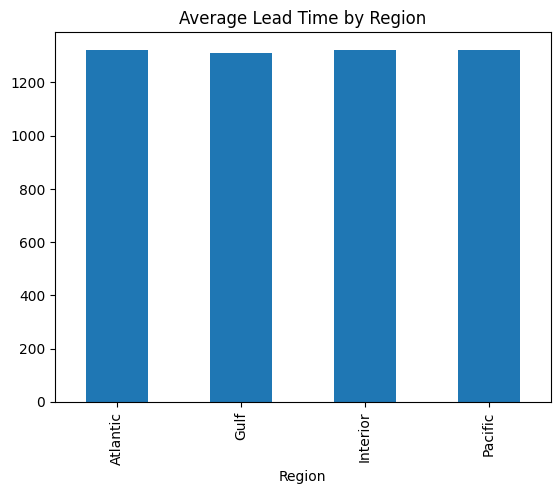

In [22]:
import matplotlib.pyplot as plt

df.groupby('Region')['Lead Time'].mean().plot(kind='bar')

plt.title("Average Lead Time by Region")

plt.show()

In [23]:
from sklearn.preprocessing import LabelEncoder

le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()
le4 = LabelEncoder()

df['Product_Encoded'] = le1.fit_transform(df['Product Name'])
df['Factory_Encoded'] = le2.fit_transform(df['Factory'])
df['Region_Encoded'] = le3.fit_transform(df['Region'])
df['ShipMode_Encoded'] = le4.fit_transform(df['Ship Mode'])

In [24]:
from sklearn.model_selection import train_test_split

X = df[
[
'Product_Encoded',
'Factory_Encoded',
'Region_Encoded',
'ShipMode_Encoded',
'Sales',
'Units',
'Cost',
'Gross Profit'
]
]

y = df['Lead Time']

X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train,y_train)

RandomForestRegressor()

In [26]:
from sklearn.metrics import mean_absolute_error,r2_score

pred = model.predict(X_test)

print("MAE =",mean_absolute_error(y_test,pred))
print("R2 =",r2_score(y_test,pred))

MAE = 225.26988665055163
R2 = -0.08864219216571123


In [39]:
from google.colab import files

files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
recommendations = df.groupby(
    ["Product Name","Factory"]
)["Lead Time"].mean().reset_index()

recommendations = recommendations.sort_values(
    "Lead Time"
)

print(recommendations.head(20))

                         Product Name            Factory    Lead Time
2                             Fun Dip        Sugar Shack  1272.666667
4                           Kazookles  The Other Factory  1272.989583
1                Fizzy Lifting Drinks        Sugar Shack  1273.500000
7                               Nerds        Sugar Shack  1274.000000
14                          Wonka Gum     Secret Factory  1306.525000
9           Wonka Bar - Fudge Mallows      Lot's O' Nuts  1314.242024
10         Wonka Bar - Milk Chocolate    Wicked Choccy's  1316.764623
13     Wonka Bar -Scrumdiddlyumptious      Lot's O' Nuts  1320.641957
12  Wonka Bar - Triple Dazzle Caramel    Wicked Choccy's  1325.661042
11  Wonka Bar - Nutty Crunch Surprise      Lot's O' Nuts  1328.915470
6                  Lickable Wallpaper     Secret Factory  1339.138298
5                         Laffy Taffy        Sugar Shack  1383.100000
8                           SweeTARTS        Sugar Shack  1383.500000
0              Everl

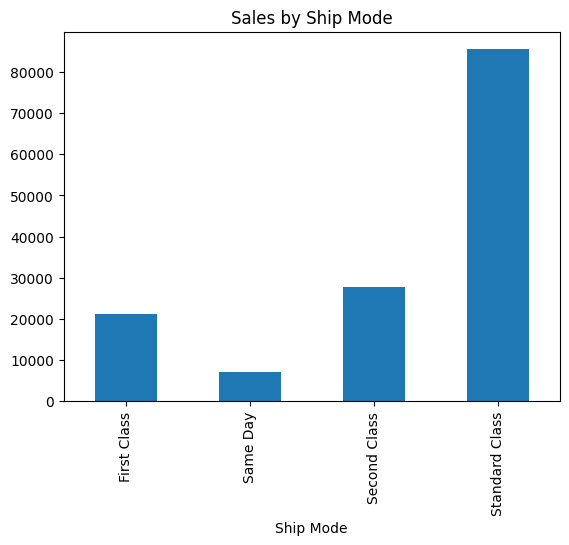

In [29]:
df.groupby('Ship Mode')['Sales'].sum().plot(kind='bar')

plt.title("Sales by Ship Mode")
plt.show()

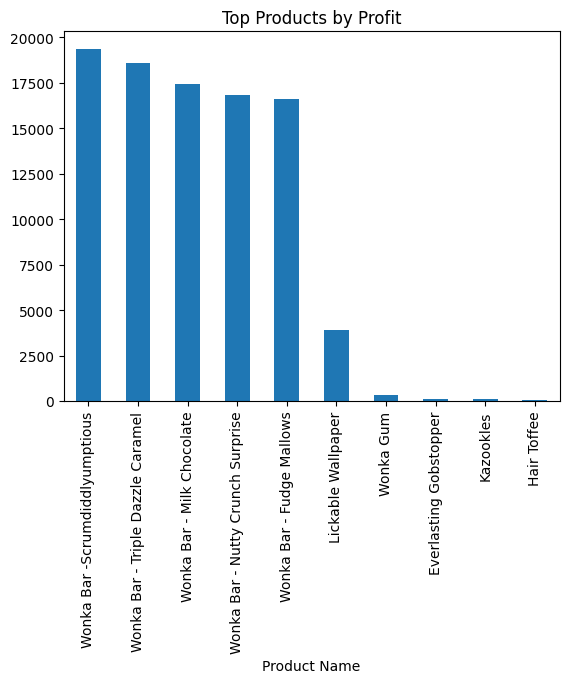

In [30]:
df.groupby('Product Name')['Gross Profit'].sum().sort_values(
ascending=False
).head(10).plot(kind='bar')

plt.title("Top Products by Profit")
plt.show()